# Computational Astrophysics: Day 3

## Common Probability Distributions

**Kris Sens**

This notebook follows the Day 3 work in the order that I completed it. It combines the code with the explanations from my notes, including transformations of random variables, estimators, common univariate distributions, density estimation, the Central Limit Theorem and the generalised Monty Hall simulation.

The main reading was **Chapter 3, pages 81--108, of _Statistics, Data Mining and Machine Learning in Astronomy_**.


## 1. Imports

These are the packages used throughout the different exercises. Some are repeated later because the original work was written across separate pieces of code.


In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
import scipy.stats
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture

## 2. Initial Pandas and Matplotlib Practice

Before moving fully into the probability distributions, I spent some time practising basic Pandas objects, importing and exporting data, and creating plots using Matplotlib.

These sections remain commented because they were exploratory practice rather than the main Day 3 analysis.


In [2]:
# random_data = pd.DataFrame(["car", "phone", "water"])

# car = pd.Series(["BMW", "Mercedes", "Toyota"])
# colour = pd.Series(["red", "blue", "pink"])
# random_data2 = pd.DataFrame({
#     "car type": car,
#     "colour": colour
# })


# #Importing data

# # pd.read_csv()
# # pd.read_excel()

# #Exporting data

# # colour.to_csv("")

In [ ]:
#Going onto plotting:
# x = [1,2,3,4]
# y = [5,6,7,8]

# fig, ax = plt.subplots() # add an axes (individual plot)
# ax.plot(x,y)
# ax.set(title = "Random Sample Plot", xlabel = "x-axis", ylabel = "y-axis")

# x = np.linspace(1,10,100)
# fig,ax = plt.subplots()
# # ax.plot(x,x**2)
# # ax.scatter(x,np.exp(x))
# ax.scatter(x, np.sin(x))
# plt.show()

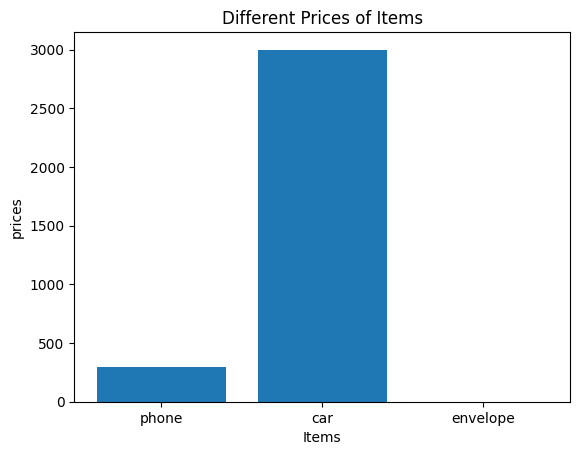

In [4]:
different_prices = {
    "phone": 300,
    "car": 3000,
    "envelope":1
}

fig,ax = plt.subplots()
ax.bar(different_prices.keys(), different_prices.values())
ax.set(title = "Different Prices of Items", xlabel = "Items", ylabel ="prices")
plt.show()

### 5.3 Comparing Distribution Shapes

The following code creates Gaussian, Laplace, cosine and uniform probability densities. The original plotting section remains commented as it was in the working file.


In [ ]:
x = np.linspace(5, -5, 2001)
gaussian_pdf = stats.norm(loc = 0, scale = 1).pdf(x)
laplace_pdf = stats.laplace(loc = 0, scale = 1).pdf(x)
cosine_pdf = stats.cosine(loc = 0, scale = 1).pdf(x)
uniform_pdf = stats.uniform(loc = 2, scale = 4).pdf(x)

# fig, axes = plt.subplots(2,1,figsize=(7, 8),sharex=True)



# axes[0].plot(x, x)

# axes[1].plot(x, laplace_pdf, "--",
#              label=r"Laplace, $K=3$")
# axes[1].plot(x, gaussian_pdf, "-",
#              label=r"Gaussian, $K=0$")
# axes[1].plot(x, cosine_pdf, "-.",
#              label=r"Cosine, $K=-0.59$")
# axes[1].plot(x, uniform_pdf, ":",
#              label=r"Uniform, $K=-1.2$")

# axes[0].set_ylabel(r"$p(x)$")
# axes[1].set_ylabel(r"$p(x)$")
# axes[1].set_xlabel(r"$x$")

# axes[0].legend()
# axes[1].legend()

# plt.tight_layout()
# plt.show()

### Gaussian and Cauchy Comparison

This comparison shows that the Cauchy distribution has a central peak similar to the Gaussian but much heavier tails.


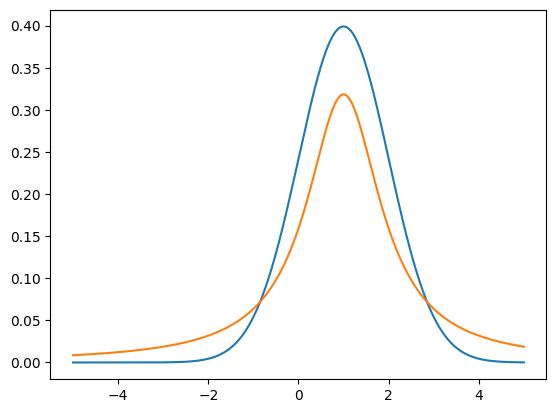

In [ ]:
gaussian = scipy.stats.norm(loc = 1, scale = 1)
cauchy = scipy.stats.cauchy(loc =1, scale = 1)

x = np.linspace(-5,5,1000)

fig, ax = plt.subplots()
ax.plot(x, gaussian.pdf(x), label = "Gaussian")
ax.plot(x, cauchy.pdf(x), label = "Gaussian")

The second curve's legend label also reads `"Gaussian"` in the original working code. It has been left as written rather than silently changed.


## 6. Estimating an Unknown Density

A histogram, a kernel density estimate and a Gaussian mixture model are three different ways of estimating the distribution which generated a sample.

- A histogram is non-parametric but depends strongly on the bin locations and widths
- A kernel density estimate places a smooth kernel around every observation and depends on the bandwidth
- A Gaussian mixture model assumes that the density can be represented as a weighted sum of Gaussian components

The generated sample below is actually a mixture of several Cauchy distributions. This makes it useful for comparing how the three density estimates behave when the true components are not Gaussian.


In [7]:
from sklearn.neighbors import KernelDensity
from astropy.visualization import hist
from sklearn.mixture import GaussianMixture


if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=14, usetex=True)

The astroML plotting helper is called with `usetex=True` in the original code. This requires working LaTeX. 

In [ ]:
plt.rcParams["text.usetex"] = False

# Generate data
random_state = np.random.RandomState(seed=0)
N = 2000

mu_gamma_f = [
    (5, 1.0, 0.1),
    (7, 0.5, 0.5),
    (9, 0.1, 0.1),
    (12, 0.5, 0.2),
    (14, 1.0, 0.1),
]

def hx(values):
    return sum(
        fraction * stats.cauchy(loc=mu, scale=gamma).pdf(values)
        for mu, gamma, fraction in mu_gamma_f
    )

x = np.concatenate([
    stats.cauchy(loc=mu, scale=gamma).rvs(
        size=int(fraction * N),
        random_state=random_state,
    )
    for mu, gamma, fraction in mu_gamma_f
])

random_state.shuffle(x)
x = x[(x > -10) & (x < 30)]

The extreme Cauchy draws are restricted to the interval \(-10<x<30\) for visualisation. The retained sample is then compared with a 100-bin histogram, a Gaussian-kernel density estimate and a 13-component Gaussian mixture model.


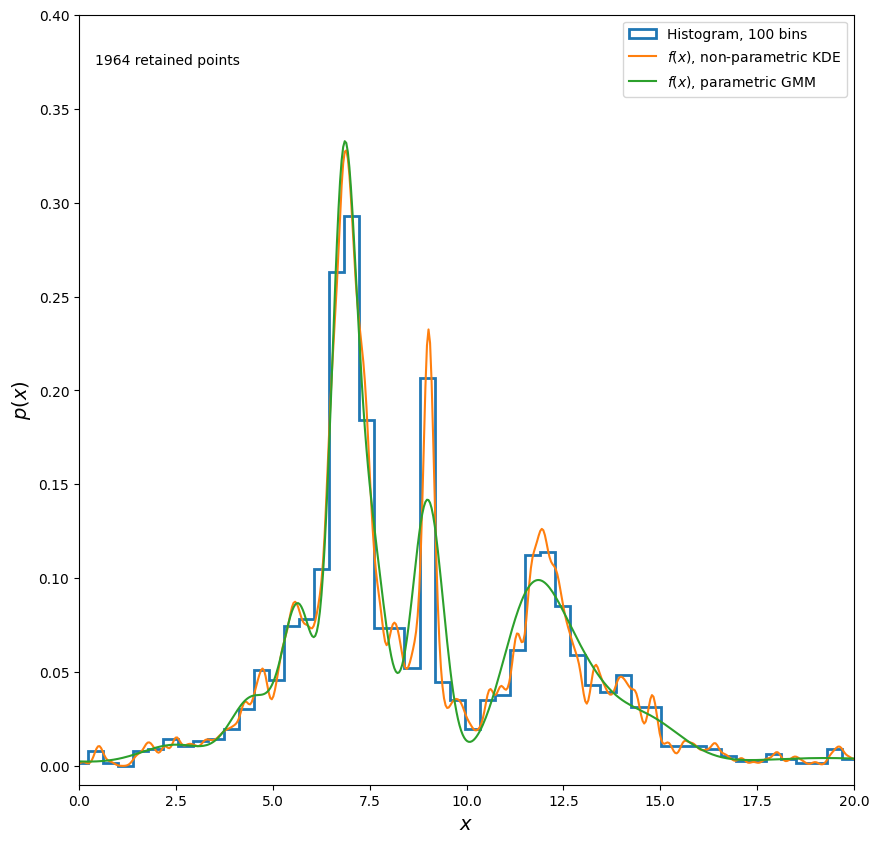

In [ ]:
# Plotting grid
fig, ax = plt.subplots(figsize=(10, 10))
xgrid = np.linspace(-10, 30, 1000)

# Histogram
ax.hist(
    x,
    density=True,
    bins=100,
    histtype="step",
    linewidth=2,
    label="Histogram, 100 bins",
)

# Kernel density estimate
kde = KernelDensity(bandwidth=0.1, kernel="gaussian")
kde.fit(x[:, None])

dens_kde = np.exp(
    kde.score_samples(xgrid[:, None])
)

ax.plot(
    xgrid,
    dens_kde,
    label=r"$f(x)$, non-parametric KDE",
)

# Gaussian mixture model
gmm = GaussianMixture(
    n_components=13,
    random_state=0,
)

gmm.fit(x[:, None])

dens_gmm = np.exp(
    gmm.score_samples(xgrid[:, None])
)

ax.plot(
    xgrid,
    dens_gmm,
    label=r"$f(x)$, parametric GMM",
)

# Optional true generating density
# ax.plot(
#     xgrid,
#     hx(xgrid),
#     ":",
#     label=r"$h(x)$, generating distribution",
# )

ax.text(
    0.02,
    0.95,
    f"{len(x)} retained points",
    ha="left",
    va="top",
    transform=ax.transAxes,
)

ax.set_xlabel(r"$x$", fontsize=14)
ax.set_ylabel(r"$p(x)$", fontsize=14)
ax.set_xlim(0, 20)
ax.set_ylim(-0.01, 0.4001)
ax.legend(loc="upper right")

plt.show()

### 6.1 Interpreting the Density Estimates

The KDE is flexible because it does not assume that the data follow a particular named distribution. However, the bandwidth controls how smooth the result is. A bandwidth which is too small can follow noise, while a bandwidth which is too large can merge the structure we want to see.

The GMM is parametric because it assumes a weighted sum of Gaussian component. Increasing the number of components increases its flexibility, but too many components can begin to model random fluctuations rather than the density.


### 7.1 A Uniform Distribution Demonstration

The following small addition repeatedly draws samples from a uniform distribution and records their means. As the sample size increases, the distribution of those means becomes narrower and more Gaussian like.


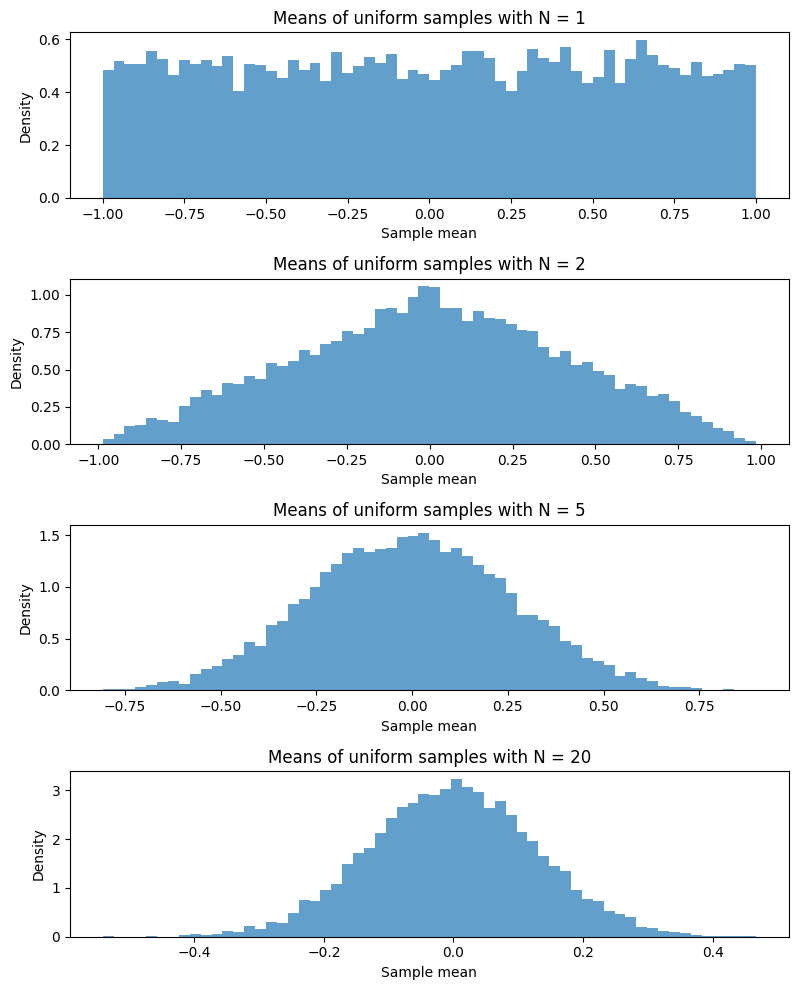

In [10]:
rng = np.random.default_rng(0)

number_of_repetitions = 10000
sample_sizes = [1, 2, 5, 20]

fig, axes = plt.subplots(
    len(sample_sizes),
    1,
    figsize=(8, 10)
)

for ax, sample_size in zip(axes, sample_sizes):
    samples = rng.uniform(
        low=-1,
        high=1,
        size=(number_of_repetitions, sample_size)
    )
    sample_means = np.mean(samples, axis=1)

    ax.hist(
        sample_means,
        bins=60,
        density=True,
        alpha=0.7
    )
    ax.set_title(
        f"Means of uniform samples with N = {sample_size}"
    )
    ax.set_xlabel("Sample mean")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

## 8. Generalised Monty Hall Simulation

This simulation generalises the ordinary three-door problem to any number of doors.

- One randomly selected door contains the prize
- The contestant chooses one door
- The host opens $n_{\mathrm{doors}}-2$ unchosen goat doors
- The two remaining closed doors are the contestant's choice and one other door

The three strategies are:

- `keep`: retain the original choice
- `switch`: move to the other unopened door
- `external`: choose randomly between the final two doors without knowing which one was selected first


{'switch': np.float64(0.89934), 'keep': np.float64(0.10212), 'external': np.float64(0.50168)}


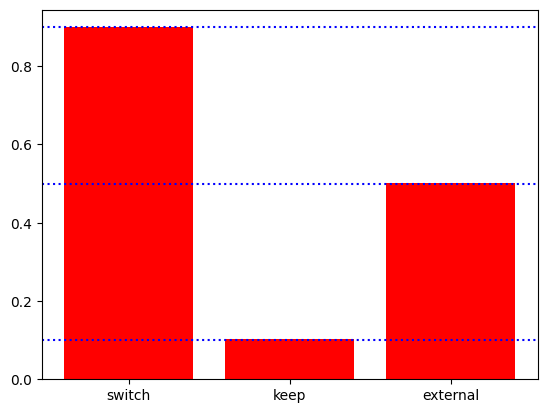

In [11]:
import numpy as np
from matplotlib import pyplot as plt


def threedoors(which, n_doors):

    labels = np.arange(n_doors)
    doors = np.zeros(n_doors, dtype =int)
    doors[np.random.choice(labels)] = 1
    choice = np.random.choice(labels)
    notchosen = np.delete(labels, choice)

    opened = []

    while len(opened) < n_doors - 2:
        to_open = np.random.choice(notchosen)
        if doors[to_open] == 0 and to_open not in opened:
            opened.append(to_open)


    other = int(np.delete(labels, opened + [choice])[0])



    if which == "switch":
        return doors[other]

    elif which == "keep":
        return doors[choice]

    elif which == "external":
        picked = np.random.choice([choice, other])
        return doors[picked]


N = int(100000)
n_doors = 10
probs = {}

for which in ["switch", "keep", "external"]:
    events = [threedoors(which, n_doors) for i in range(N)]
    probs[which] = np.sum(events)/ N

print(probs)

plt.bar([0,1,2], [probs[k] for k in probs.keys()], color = "r")
plt.xticks([0,1,2], probs.keys())

for y in [1 / n_doors, 1 / 2, (n_doors - 1) / n_doors]:
    plt.axhline(y, ls=":", c="b")

plt.show()

### 8.1 Why the External Observer Gets $1/2$

The contestant knows which door was chosen before the host acted. That information distinguishes the original door from the other remaining door.

An external observer who enters only after the host has finished and does not know which door was selected originally sees two apparently equivalent closed doors. Their probability of winning by choosing randomly is therefore $1/2$.

This shows that the probabilities depend on the present information.


## Resources Used

### My own notes

- [Computational Astrophysics Day 3 LaTeX notes](https://www.overleaf.com/read/kwqrkscvbjzx#a29eaf)

### Main reading

- _Statistics, Data Mining and Machine Learning in Astronomy_, Chapter 3, pages 81--108

### Astrostatistics lecture

- [Astrostatistics Lecture 2](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/lectures/L02_probability.ipynb)

### astroML Chapter 3

- [Overview of Probability and Random Variables](https://www.astroml.org/astroML-notebooks/chapter3/astroml_chapter3_Overview_of_Probability_and_Random_Variables.html)
- [Univariate Distribution Functions](https://www.astroml.org/astroML-notebooks/chapter3/astroml_chapter3_Univariate_Distribution_Functions.html)
- [The Central Limit Theorem](https://www.astroml.org/astroML-notebooks/chapter3/astroml_chapter3_The_Central_Limit_Theorem.html)

### Python learning

- [Zero to Mastery NumPy introduction](https://dev.mrdbourke.com/zero-to-mastery-ml/introduction-to-numpy/)
- [Zero to Mastery Pandas introduction](https://dev.mrdbourke.com/zero-to-mastery-ml/introduction-to-pandas/)

### Python documentation

- [SciPy statistical distributions](https://docs.scipy.org/doc/scipy/reference/stats.html)
- [scikit-learn KernelDensity](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KernelDensity.html)
- [scikit-learn GaussianMixture](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html)
